In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

qu_data = pd.read_csv("validation_data/Wang_fig7.csv")
cubes_data = pd.read_csv("output/eplusout.csv")
floor_area = 85

In [5]:
time = np.arange(1,13)
qucols = qu_data.columns
qu_data.head()

,month,measured natural gas consumption [kWh],simulated natural gas consumption [kWh],measured grid electricity consumption [kWh],simulated grid electricity consumption [kWh]
0,1,3881.944444,4006.944444,951.388889,1013.888889
1,2,3368.055556,3472.222222,409.722222,493.055556
2,3,3416.666667,3583.333333,361.111111,402.777778
3,4,2090.277778,2194.444444,263.888889,333.333333
4,5,1444.444444,1604.166667,388.888889,347.222222


In [6]:
def get_month(datestring):
    month = datestring.split("/")[0][0:3]
    return int(month)

In [7]:
print(get_month(cubes_data["Date/Time"].values[-1]))
cubes_data["month"]=cubes_data["Date/Time"].apply(get_month)

12


In [8]:
cubes_data_by_month = cubes_data.groupby("month").sum()
ccols = cubes_data_by_month.columns
cubes_data_by_month

/tmp/ipykernel_844/3981637042.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  cubes_data_by_month = cubes_data.groupby("month").sum()


,Environment:Site Outdoor Air Drybulb Temperature [C](Hourly),BLOCK LIVING STOREY 0:Zone Air Temperature [C](Hourly),BLOCK LIVING STOREY 0:Zone Air Relative Humidity [%](Hourly),BLOCK LIVING STOREY 1:Zone Air Temperature [C](Hourly),BLOCK LIVING STOREY 1:Zone Air Relative Humidity [%](Hourly),ROOF SPACE:Zone Air Temperature [C](Hourly),ROOF SPACE:Zone Air Relative Humidity [%](Hourly),Whole Building:Facility Total HVAC Electricity Demand Rate [W](Hourly),MAIN BOILER:Boiler NaturalGas Rate [W](Hourly),Site:Environmental Impact Total CO2 Emissions Carbon Equivalent Mass [kg](Hourly)
month,,,,,,,,,,
1,3468.616667,15695.799426,23468.564553,15743.515886,23324.418860,17578.995329,23051.800453,4.333636e+06,3.969386e+07,2601.753167
2,4592.266667,14062.353442,23205.393095,14184.222124,22934.583343,13898.133255,25208.864514,4.328920e+06,4.252669e+07,2665.874827
3,5492.875000,15984.013343,25075.097078,16221.935651,24599.271474,14740.100576,29431.365980,4.521500e+06,2.632831e+07,1750.167727
4,6485.491667,15292.045541,25420.612965,15333.130794,25299.442868,15250.894185,28027.599629,4.598689e+06,1.346978e+08,7708.299446
5,9673.691667,15563.077268,34641.858365,15567.539780,34593.385458,17724.377749,33637.557647,4.970918e+06,1.574940e+08,8981.505790
6,11147.666667,15545.114182,33997.540317,15624.891465,33765.568958,19088.800817,31098.562397,3.508176e+06,7.190019e+07,4193.848620
7,13881.658333,17184.091736,37793.373300,17379.903072,37267.307729,21453.121530,33571.424171,2.019141e+06,2.294192e+07,1422.047287
8,13909.450000,17237.359809,38835.273883,17422.351377,38295.608678,21470.033565,34767.796385,1.629579e+06,1.461476e+07,942.834462
9,10222.516667,15166.536666,38063.073049,15199.186130,37924.686690,17299.737249,36363.619089,4.022954e+06,1.073496e+08,6171.026597


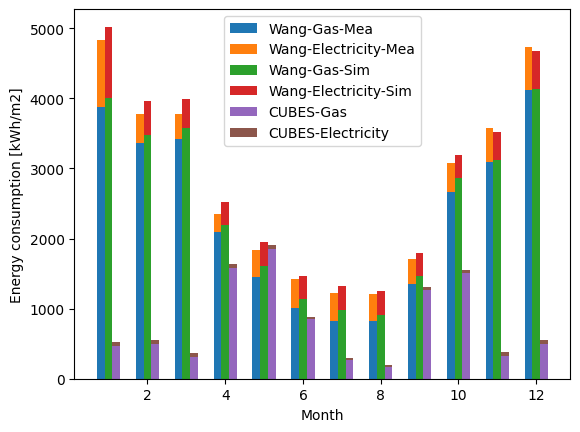

In [11]:
width = 0.2
fig,ax = plt.subplots()
ax.bar(time-width,qu_data[qucols[1]],width,label='Wang-Gas-Mea')
ax.bar(time-width,qu_data[qucols[3]],width,bottom=qu_data[qucols[1]],label='Wang-Electricity-Mea')
ax.bar(time,qu_data[qucols[2]],width,label='Wang-Gas-Sim')
ax.bar(time,qu_data[qucols[4]],width,bottom=qu_data[qucols[2]],label='Wang-Electricity-Sim')
ax.bar(time+width,cubes_data_by_month[ccols[-2]]/1000/floor_area,width,label='CUBES-Gas')
ax.bar(time+width,cubes_data_by_month[ccols[-3]]/1000/floor_area,width,bottom=cubes_data_by_month[ccols[-2]]/1000/floor_area,label='CUBES-Electricity')
ax.set_xlabel('Month')
ax.set_ylabel('Energy consumption [kWh/m2]')
ax.legend()

NameError: name 'singh_energy' is not defined